# Hackalysis

This notebook contains detailed analysis of the hackathon repositories, including metadata and concept extraction. The goal is to understand the lifecycle of project contributions in relation to hackathon events. Also, to be able to detect Hackathon repositories through various signals

In [178]:
from __future__ import annotations

import json
import os
from pathlib import Path

from dotenv import load_dotenv
import pandas as pd

load_dotenv()

DATA_ROOT = Path(os.getenv('DATA_ROOT'))
PROVIDER_PREFIX = 'lauzhack'

## Project Based Analysis

### Create Project Based Analysis Data set 

In this data set there is 1 row per project and repo meta data is appended as a list of dicts. This allows us to do project based analysis and also to have all the repos of a project together.

In [179]:
def _load_hackathon_metadata_row(metadata_json_path: Path, year: int) -> dict:
    metadata = json.loads(metadata_json_path.read_text(encoding='utf-8'))
    if isinstance(metadata, list):
        metadata = metadata[0] if metadata else {}
    if not isinstance(metadata, dict):
        metadata = {}

    row = {f'hackathon_{k}': v for k, v in metadata.items()}
    row['hackathon_year'] = year
    return row


def load_projects_analysis_ready(data_root: Path, provider_prefix: str = 'lauzhack') -> pd.DataFrame:
    frames: list[pd.DataFrame] = []

    for folder in sorted(data_root.glob(f'{provider_prefix}-*')):
        if not folder.is_dir():
            continue

        year_str = folder.name.split('-')[-1]
        if not year_str.isdigit():
            continue
        year = int(year_str)

        projects_path = folder / f'{provider_prefix}_projects.parquet'
        github_projects_path = folder / f'{provider_prefix}_github_project_metadata.parquet'
        metadata_json_path = folder / f'{provider_prefix}_metadata.json'

        if not projects_path.exists() or not metadata_json_path.exists():
            continue

        # Prefer project-level GitHub-enriched file when present.
        source_path = github_projects_path if github_projects_path.exists() else projects_path
        df = pd.read_parquet(source_path).copy()
        df['year'] = year

        metadata_row = _load_hackathon_metadata_row(metadata_json_path, year)
        for col, val in metadata_row.items():
            if isinstance(val, (list, dict, tuple, set)):
                df[col] = [val for _ in range(len(df))]
            else:
                df[col] = val

        frames.append(df)

    if not frames:
        return pd.DataFrame()

    merged = pd.concat(frames, ignore_index=True)

    # Harmonize expected GitHub columns even when some years have no github_project_metadata file.
    if 'github_repo_urls' not in merged.columns:
        merged['github_repo_urls'] = [[] for _ in range(len(merged))]
    if 'github_repos_metadata' not in merged.columns:
        merged['github_repos_metadata'] = [[] for _ in range(len(merged))]
    if 'github_repo_count' not in merged.columns:
        merged['github_repo_count'] = 0

    merged['github_repo_count'] = pd.to_numeric(merged['github_repo_count'], errors='coerce').fillna(0).astype(int)

    # Global key for cross-year/provider uniqueness.
    if 'project_uid' in merged.columns:
        merged['global_project_uid'] = merged.apply(
            lambda r: f"{provider_prefix}:{int(r['year'])}:{r['project_uid']}" if pd.notna(r.get('project_uid')) else f"{provider_prefix}:{int(r['year'])}:row:{r.name}",
            axis=1,
        )
    else:
        merged['global_project_uid'] = merged.apply(
            lambda r: f"{provider_prefix}:{int(r['year'])}:row:{r.name}", axis=1
        )

    return merged

#### Exploratory Data Analysis

In [180]:
projects_df = load_projects_analysis_ready(DATA_ROOT, PROVIDER_PREFIX)
print(f"Loaded {len(projects_df)} projects across all years.\n rows = {len(projects_df)} \n columns = {len(projects_df.columns)}")
projects_df.columns


def _canonicalize(v):
    if v is None:
        return ""

    try:
        if pd.isna(v):
            return ""
    except Exception:
        pass

    if isinstance(v, str):
        s = v.strip()
        if not s:
            return ""
        try:
            v = json.loads(s)
        except Exception:
            return s

    if isinstance(v, dict):
        return json.dumps(v, ensure_ascii=False, sort_keys=True)

    if isinstance(v, (list, tuple, set)):
        items = [str(x).strip() for x in v if x is not None and str(x).strip()]
        items = sorted(items)
        return json.dumps(items, ensure_ascii=False)

    return str(v).strip()



projects_df["awards"] = projects_df["awards"].map(_canonicalize)
projects_df["categories"] = projects_df["categories"].map(_canonicalize)
projects_df["team"] = projects_df["team"].map(_canonicalize)
projects_df["github_repo_urls"] = projects_df["github_repo_urls"].map(_canonicalize)


projects_df["title"] = projects_df["title"].map(_canonicalize)
projects_df["project_title"] = projects_df["project_title"].map(_canonicalize)

to_be_dropped_col = []

if (projects_df["awards"].equals(projects_df["categories"])):
    to_be_dropped_col.append("categories")
if projects_df["title"].equals(projects_df["project_title"]):
    to_be_dropped_col.append("project_title")
if projects_df['hackathon_year'].equals(projects_df['year']):
    to_be_dropped_col.append('hackathon_year')

non_analysis_cols = ['hackathon_name', 'hackathon_location', 'hackathon_source_url', 'hackathon_description', 'hackathon_date', 'hackathon_social_links', 'hackathon_extracted_at'] # I am dropping these columns because for now we only focus on lauzhack so year column is enough to ideantify the hackathon
to_be_dropped_col.extend(non_analysis_cols)
to_be_dropped_col.extend(['project_uid', 'id', 'project_id','image_url', 'tags']) # I am dropping this column because it is just a unique identifier and does not have any meaning for analysis

projects_df.drop(columns=to_be_dropped_col, inplace=True)

print(f"After dropping columns: \n columns = {len(projects_df.columns)} \n sample columns = {projects_df.columns.tolist()}")

# Convert hackathon_date to datetime

projects_df['hackathon_date_start'] = pd.to_datetime(projects_df['hackathon_date_start'], errors='coerce')
projects_df['hackathon_date_end'] = pd.to_datetime(projects_df['hackathon_date_end'], errors='coerce')


# Create column on team size based on team column which is a list of dicts with member information

Loaded 213 projects across all years.
 rows = 213 
 columns = 27
After dropping columns: 
 columns = 12 
 sample columns = ['title', 'description', 'url', 'team', 'awards', 'github_repo_urls', 'github_repo_count', 'github_repos_metadata', 'year', 'hackathon_date_start', 'hackathon_date_end', 'global_project_uid']


In [181]:
projects_df.head()

,title,description,url,team,awards,github_repo_urls,github_repo_count,github_repos_metadata,year,hackathon_date_start,hackathon_date_end,global_project_uid
0,"SightSync, a virtual assistant for visual impa...",An app that describes the surroundings through...,https://github.com/sightsync,"[""Ferran Aran"", ""Oriol Agost Batalla""]","[""1st place overall""]","[""https://github.com/sightsync/.github"", ""http...",4,"[{""input_url"": ""https://github.com/sightsync/....",2023,2023-12-02,2023-12-03,lauzhack:2023:id:1
1,VirtuWheel,Real city driving simulator with hand pose rec...,https://github.com/alvaro-budria/VirtuWheel,"[""Jaume Ros Alonso""]","[""2nd place overall""]","[""https://github.com/alvaro-budria/VirtuWheel""]",1,"[{""input_url"": ""https://github.com/alvaro-budr...",2023,2023-12-02,2023-12-03,lauzhack:2023:id:2
2,It’s not about winning,"""It’s not about winning"" is a cutting-edge app...",https://fastmaildassdas.retool.com/apps/92b217...,"[""Gero Embser"", ""Indira Fömmel"", ""Leonard Eyer""]","[""3rd place overall"", ""AXA challenge winner""]",[],0,[],2023,2023-12-02,2023-12-03,lauzhack:2023:id:3
3,BMS detction HCM,model learning and qualtitative feedback diagn...,https://github.com/Gabriel29062001/hackathon,"[""Eddy BESSAH"", ""Grégoire Longechamp"", ""gabrie...","[""BMS challenge winner"", ""Organizers' prize""]","[""https://github.com/Gabriel29062001/hackathon""]",1,"[{""input_url"": ""https://github.com/Gabriel2906...",2023,2023-12-02,2023-12-03,lauzhack:2023:id:4
4,AWS Challenge,Our take on obtaining useful and compact infor...,https://github.com/mgil4/AWS_LAUZ,"[""Gustavo Vergara Gamboa"", ""Lola Monroy Mir"", ...","[""AWS challenge winner""]","[""https://github.com/mgil4/AWS_LAUZ""]",1,"[{""input_url"": ""https://github.com/mgil4/AWS_L...",2023,2023-12-02,2023-12-03,lauzhack:2023:id:5


In [182]:
projects_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 213 entries, 0 to 212
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   title                  213 non-null    str           
 1   description            213 non-null    str           
 2   url                    213 non-null    str           
 3   team                   213 non-null    str           
 4   awards                 213 non-null    str           
 5   github_repo_urls       213 non-null    str           
 6   github_repo_count      213 non-null    int64         
 7   github_repos_metadata  213 non-null    str           
 8   year                   213 non-null    int64         
 9   hackathon_date_start   213 non-null    datetime64[us]
 10  hackathon_date_end     213 non-null    datetime64[us]
 11  global_project_uid     213 non-null    str           
dtypes: datetime64[us](2), int64(2), str(8)
memory usage: 1.2 MB


### Remove Duplicate groups

#### Duplicate Rows Summary 

In [183]:
group_cols = ['title', 'github_repo_urls']


duplicate_projects = projects_df[projects_df.duplicated(subset=group_cols, keep=False)].sort_values('title').copy()

if duplicate_projects.empty:
    print('No duplicate groups found for', group_cols)
else:
    group_summaries = []

    for group_key, group_df in duplicate_projects.groupby(group_cols, dropna=False, sort=False):
        different_cols = [col for col in group_df.columns if group_df[col].nunique(dropna=False) > 1]
        different_cols_other_than_team = [col for col in different_cols if col != 'team']

        group_summaries.append({
            'title': group_key[0],
            'rows_in_group': len(group_df),
            'different_columns': different_cols,
            'different_columns_other_than_team': different_cols_other_than_team,
        })

        cols_to_show = ['year', 'title', 'team'] + different_cols_other_than_team
        cols_to_show = list(dict.fromkeys(col for col in cols_to_show if col in group_df.columns))

        print(f"\nDuplicate group: {group_key[0]}")
        print('Different columns:', different_cols)
        print('Different columns other than team:', different_cols_other_than_team)
        display(group_df[cols_to_show])

    pd.DataFrame(group_summaries)


Duplicate group: Amazon Review Tools
Different columns: ['team', 'global_project_uid']
Different columns other than team: ['global_project_uid']


,year,title,team,global_project_uid
16,2023,Amazon Review Tools,"[""Ali Emre Senel"", ""Lorenzo Calda""]",lauzhack:2023:id:17
17,2023,Amazon Review Tools,"[""Alberto Paolo Lolli""]",lauzhack:2023:id:18



Duplicate group: Bioicons PDB2Vector
Different columns: ['team', 'global_project_uid']
Different columns other than team: ['global_project_uid']


,year,title,team,global_project_uid
18,2023,Bioicons PDB2Vector,"[""Simon Dürr""]",lauzhack:2023:id:19
44,2023,Bioicons PDB2Vector,"[""Felix Richter"", ""Laurenz Rasche"", ""Ryoma Mae...",lauzhack:2023:id:45



Duplicate group: OpenLogs Lauzhack
Different columns: ['team', 'global_project_uid']
Different columns other than team: ['global_project_uid']


,year,title,team,global_project_uid
35,2023,OpenLogs Lauzhack,"[""Jaume López Molina""]",lauzhack:2023:id:36
59,2023,OpenLogs Lauzhack,"[""Joffre Alcivar Riera"", ""Pau Carulla Lechosa""]",lauzhack:2023:id:60


#### Duplicate row removal 

In [184]:
projects_df.info()

## Remove Duplicate rows 
dup_projects = projects_df[projects_df.duplicated(subset=['title', 'github_repo_urls', 'github_repos_metadata'], keep=False)].sort_values('title')[['year', 'title', 'github_repo_urls', 'github_repo_count', 'description', 'team', 'github_repos_metadata']]

dup_projects.groupby(['title', 'github_repo_urls', 'github_repos_metadata'], dropna=False, sort=False).size().reset_index(name='count').sort_values('count', ascending=False)
group_cols = ['title', 'description', 'github_repos_metadata']

merged_team_df = (
    projects_df
    .groupby(group_cols, dropna=False, as_index=False)
    .agg(
        merged_team=('team', lambda s: json.dumps(
            sorted({member for team in s.map(json.loads) for member in team}),
            ensure_ascii=False
        )),
        duplicate_row_count=('team', 'size'),
    )
)

projects_df_updated = projects_df.merge(
    merged_team_df,
    on=group_cols,
    how='left',
)

projects_df_updated['team'] = projects_df_updated['merged_team']
projects_df_updated['merged_from_duplicate_rows'] = projects_df_updated['duplicate_row_count'] > 1

projects_df_deduped = (
    projects_df_updated
    .drop(columns=['merged_team'])
    .drop_duplicates(subset=group_cols, keep='first')
    .reset_index(drop=True)
)

analysis_df = pd.DataFrame(projects_df_deduped[projects_df_deduped.columns.difference(['duplicate_row_count'])].copy())

<class 'pandas.DataFrame'>
RangeIndex: 213 entries, 0 to 212
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   title                  213 non-null    str           
 1   description            213 non-null    str           
 2   url                    213 non-null    str           
 3   team                   213 non-null    str           
 4   awards                 213 non-null    str           
 5   github_repo_urls       213 non-null    str           
 6   github_repo_count      213 non-null    int64         
 7   github_repos_metadata  213 non-null    str           
 8   year                   213 non-null    int64         
 9   hackathon_date_start   213 non-null    datetime64[us]
 10  hackathon_date_end     213 non-null    datetime64[us]
 11  global_project_uid     213 non-null    str           
dtypes: datetime64[us](2), int64(2), str(8)
memory usage: 1.2 MB


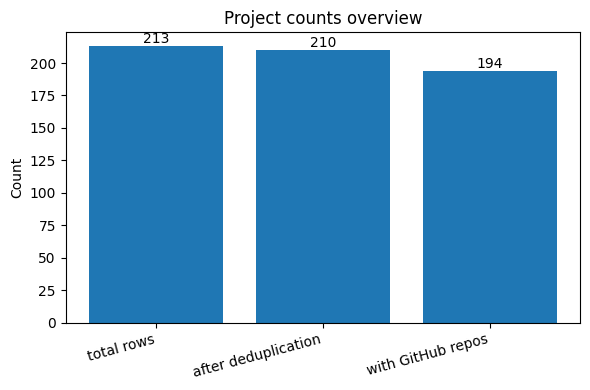

In [195]:
import matplotlib.pyplot as plt

total_projects = projects_df.shape[0]
deduped_projects = analysis_df.shape[0]
with_github = analysis_df[analysis_df['github_repo_count'] != 0].shape[0]

labels = ['total rows', 'after deduplication', 'with GitHub repos']
values = [total_projects, deduped_projects, with_github]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values)

for bar, v in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, v, str(v), ha='center', va='bottom')

plt.ylabel('Count')
plt.title('Project counts overview')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()
